# Preliminary data analysis of HIVDRD

In [20]:
import pandas as pd
from holoviews.plotting.bokeh.styles import font_size

import data_preprocessing
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import data_preprocessing

files = [r"./data/INI_DataSet.txt",  r"./data/NNRTI_DataSet.txt", r"./data/NRTI_DataSet.txt", r"./data/PI_DataSet.txt"]

## Evaluating properties of the datasets

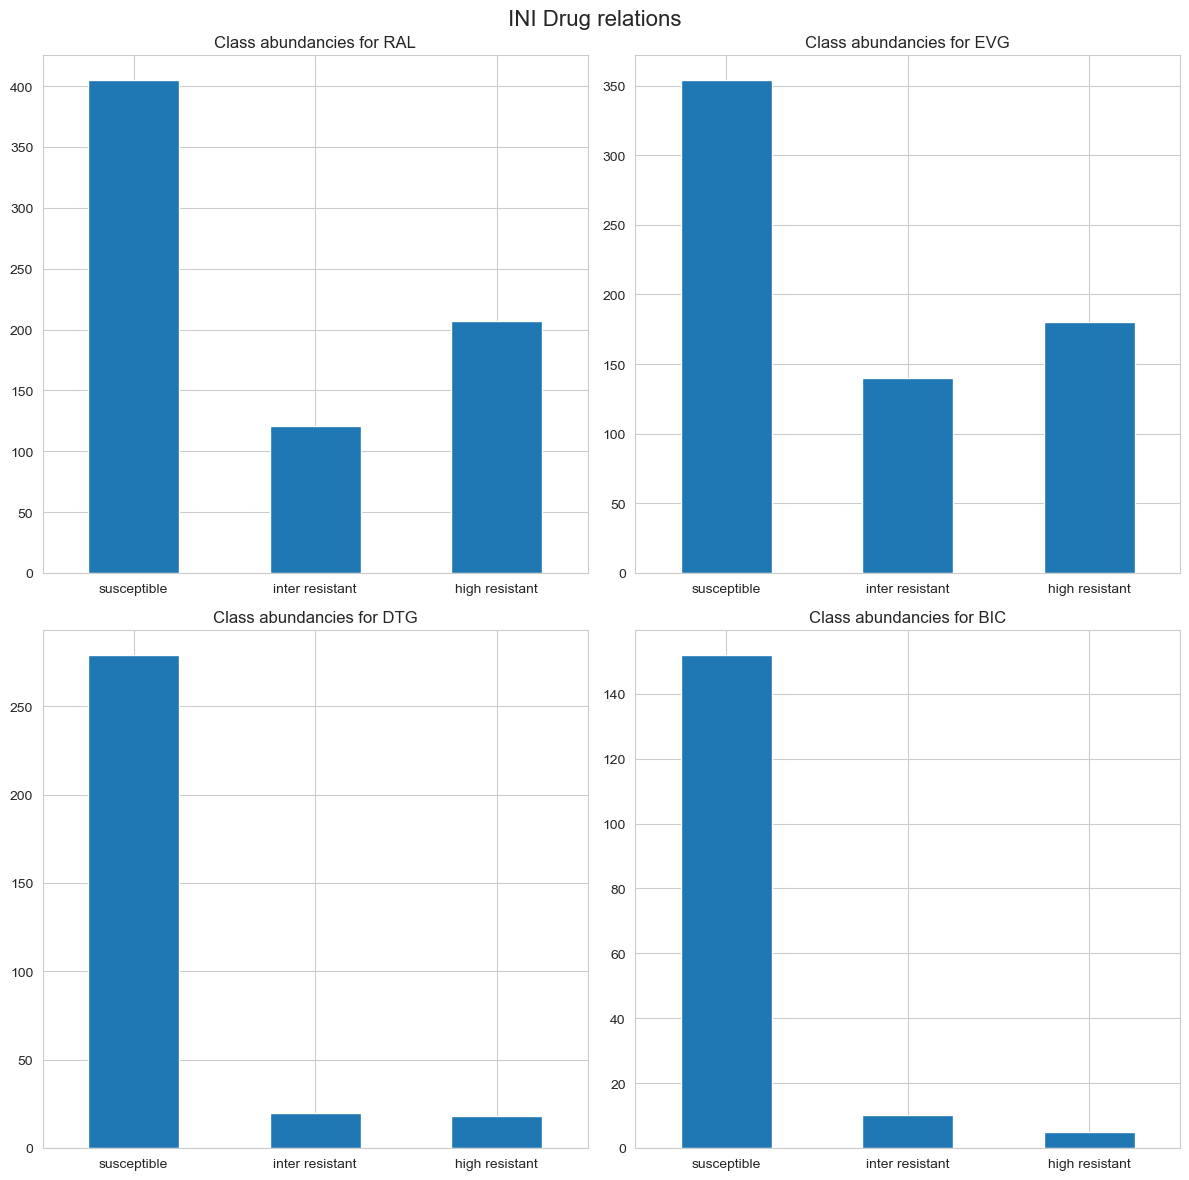

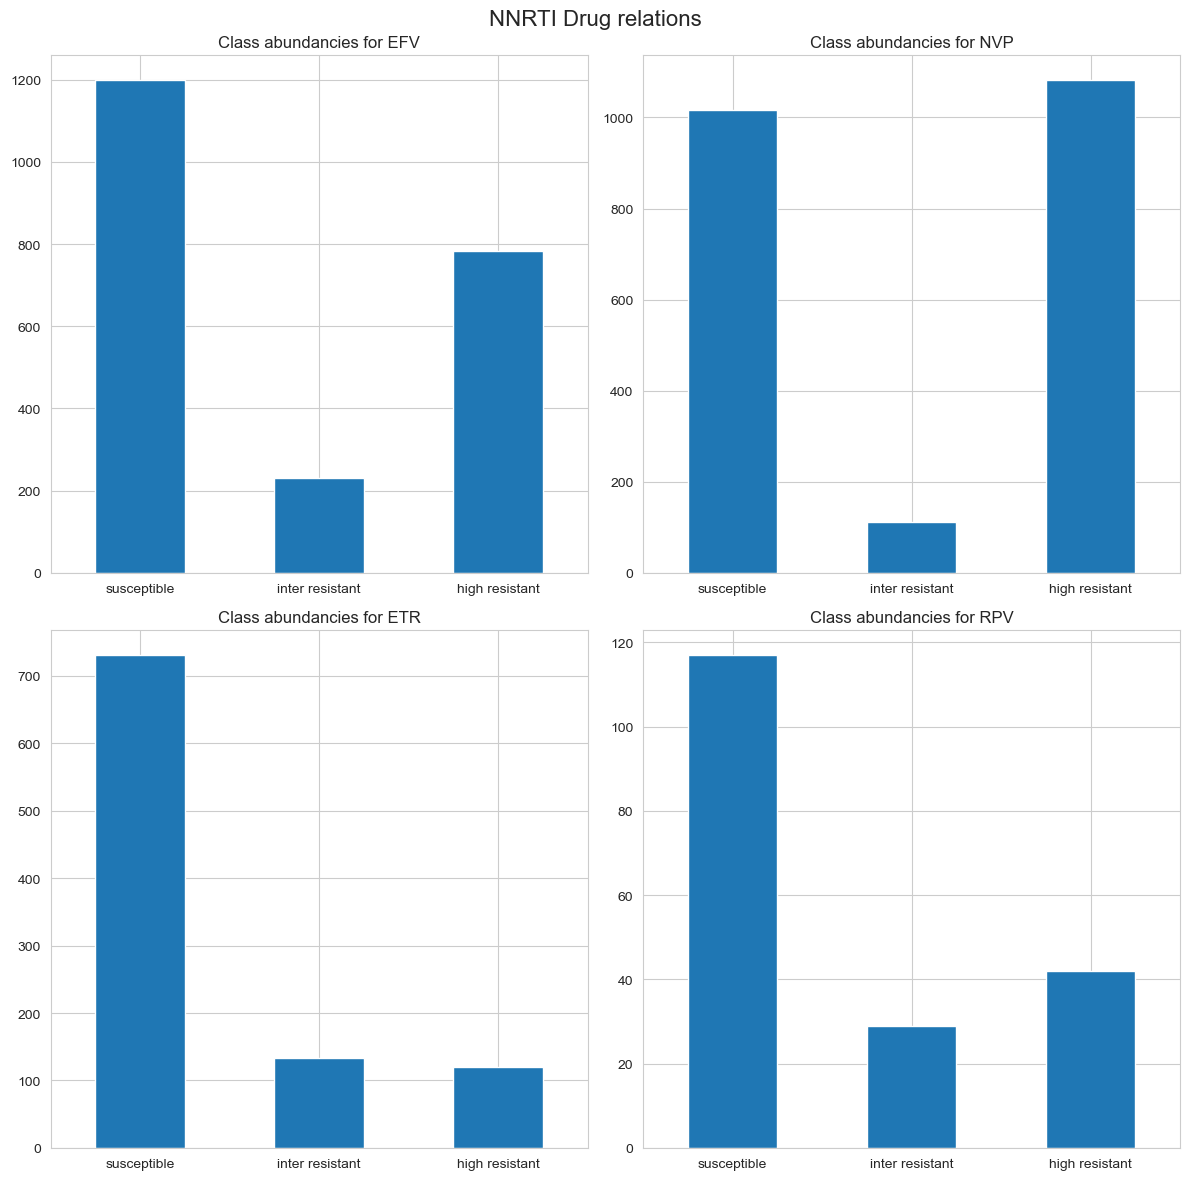

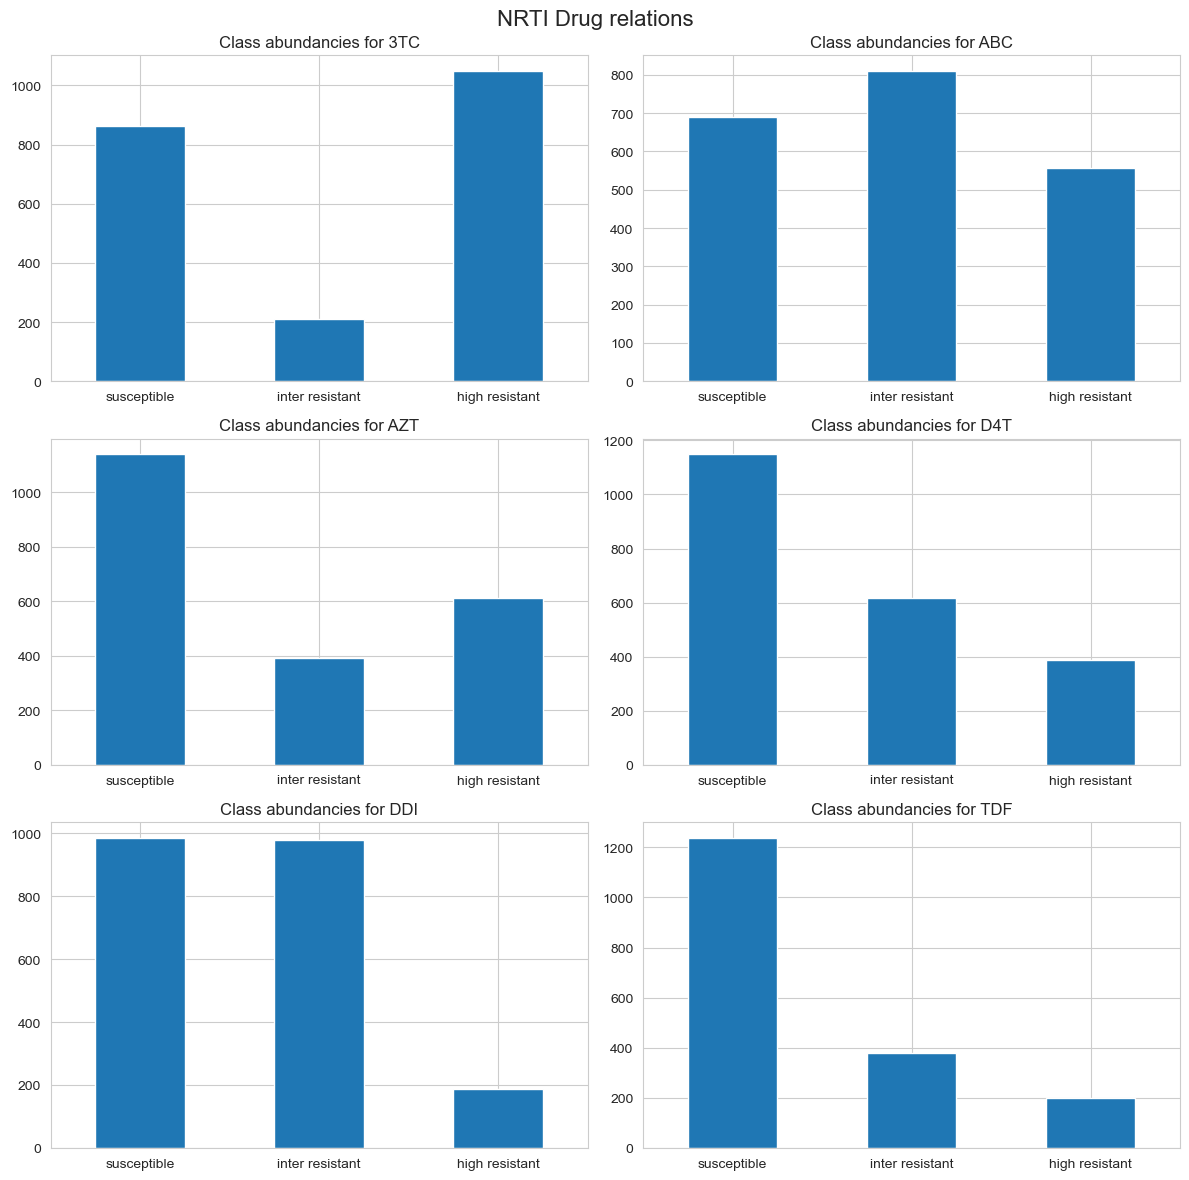

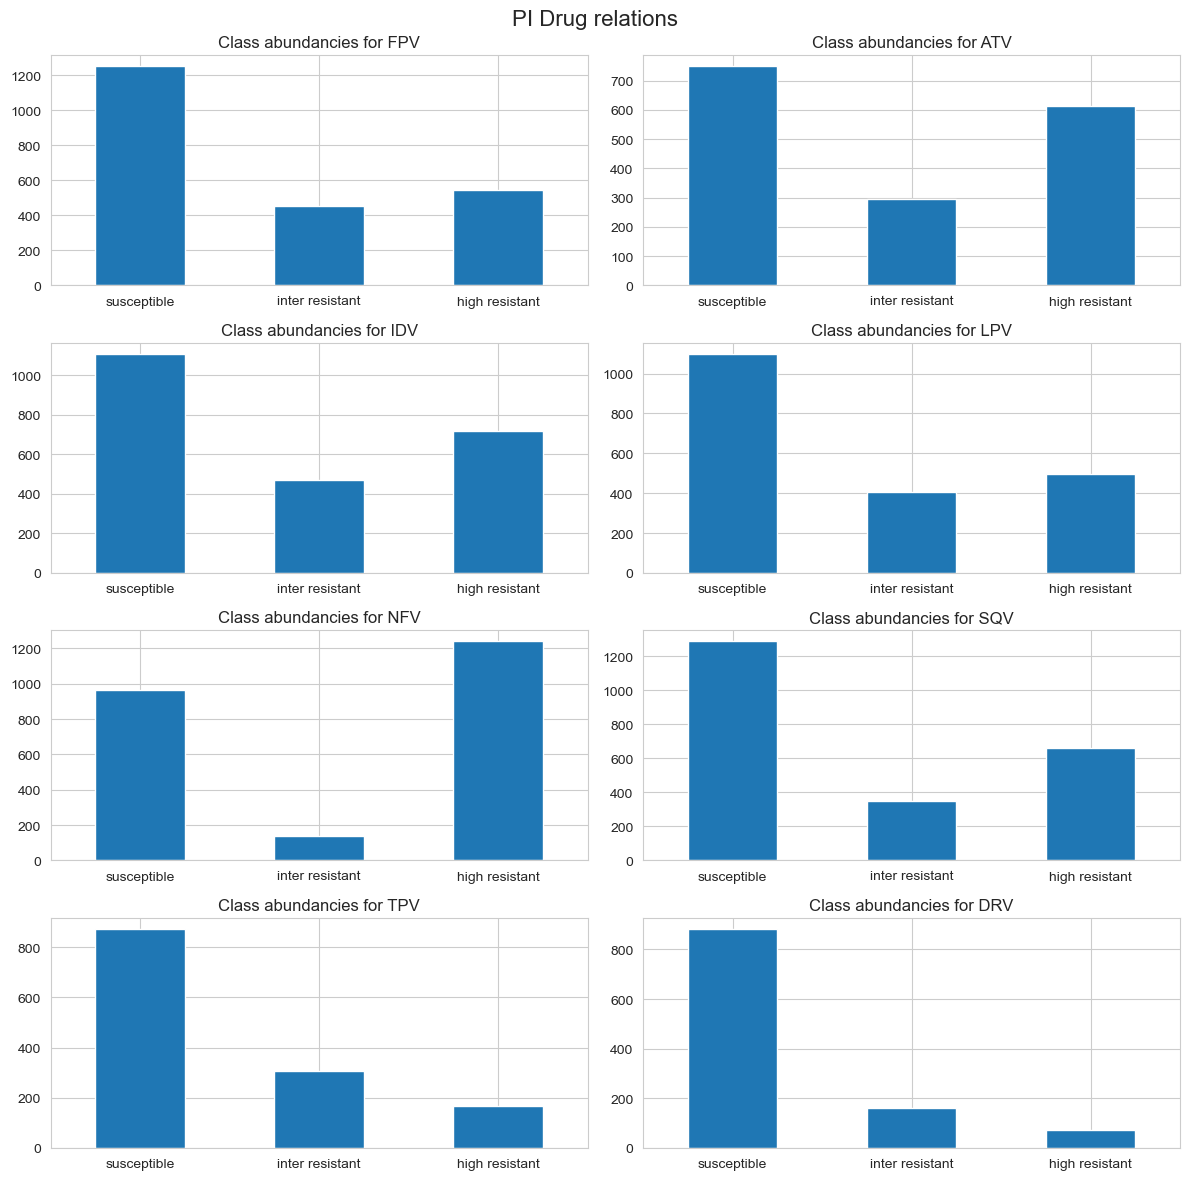

In [27]:
#checking the class imbalance per drug:

for file in files:

    _, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=False, class_mode="multiclass")


    fig, axs = plt.subplots(len(drugs) // 2 + len(drugs) % 2,2,figsize=(12,12), layout="tight")
    fig.subplots_adjust(hspace = 0.5)
    axs = axs.flatten()

    for i, drug in enumerate(drugs):

        class_counts = Y[drug].value_counts(sort=False).sort_index()

        class_counts.plot(kind="bar", ax=axs[i])
        axs[i].tick_params("x", rotation=0)
        #ax.set_ylabels("# of samples")
        axs[i].set_xticklabels(["susceptible", "inter resistant", "high resistant"])
        axs[i].set_xlabel('')
        axs[i].set_title('Class abundancies for ' + drug)

    fig.suptitle(file.split("/")[-1].strip("_DataSet.txt") + " Drug relations", fontsize=16)
    plt.show()



[0.55252387 0.16507503 0.28240109]
[0.52522255 0.20771513 0.26706231]
[0.88012618 0.06309148 0.05678233]
[0.91017964 0.05988024 0.02994012]
[0.5420434  0.10443038 0.35352622]
[0.460181   0.05022624 0.48959276]
[0.74288618 0.1351626  0.12195122]
[0.62234043 0.15425532 0.22340426]
[0.40716305 0.09849199 0.49434496]
[0.33592611 0.39377735 0.27029655]
[0.53196454 0.18292114 0.28511433]
[0.53367394 0.2861124  0.18021366]
[0.4584301  0.45471435 0.08685555]
[0.68302095 0.207828   0.10915105]
[0.5569902  0.20124666 0.24176313]
[0.45229469 0.17753623 0.37016908]
[0.48280366 0.20461471 0.31258163]
[0.54977489 0.20210105 0.24812406]
[0.41254266 0.0584471  0.52901024]
[0.56092254 0.15143603 0.28764143]
[0.64981413 0.2267658  0.12342007]
[0.79121864 0.14247312 0.06630824]


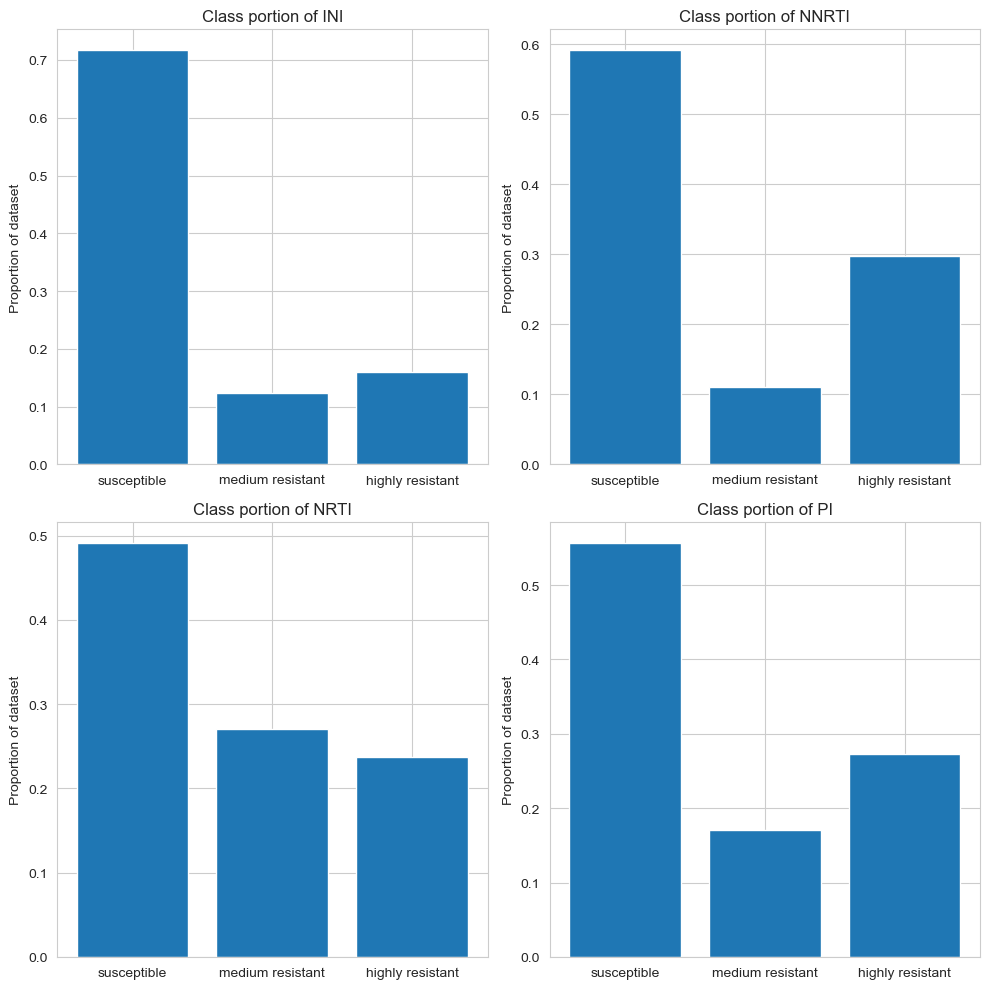

In [51]:
#checking the average class imbalance per dataset:

fig, axs = plt.subplots(2, 2, figsize=(10, 10), layout="tight")

axs = axs.flatten()

for i, file in enumerate(files):

    _, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=False, class_mode="multiclass")

    avg_label_imb = np.zeros(3)

    for drug in drugs:

        class_counts = np.array(Y[drug].value_counts(sort=False).sort_index())

        print(np.array(class_counts) / sum(np.array(class_counts)))


        avg_label_imb += class_counts / sum(class_counts)

    avg_label_imb /= len(drugs)

    ax = axs[i]

    ax.bar(["susceptible", "medium resistant", "highly resistant"], avg_label_imb)
    ax.set_ylabel("Proportion of dataset")
    #ax.tick_params("x", rotation=45)
    ax.set_title('Class portion of ' + file.split("/")[-1].strip("_DataSet.txt"))

plt.savefig("./figures/target_properties/class_imbalance.png")


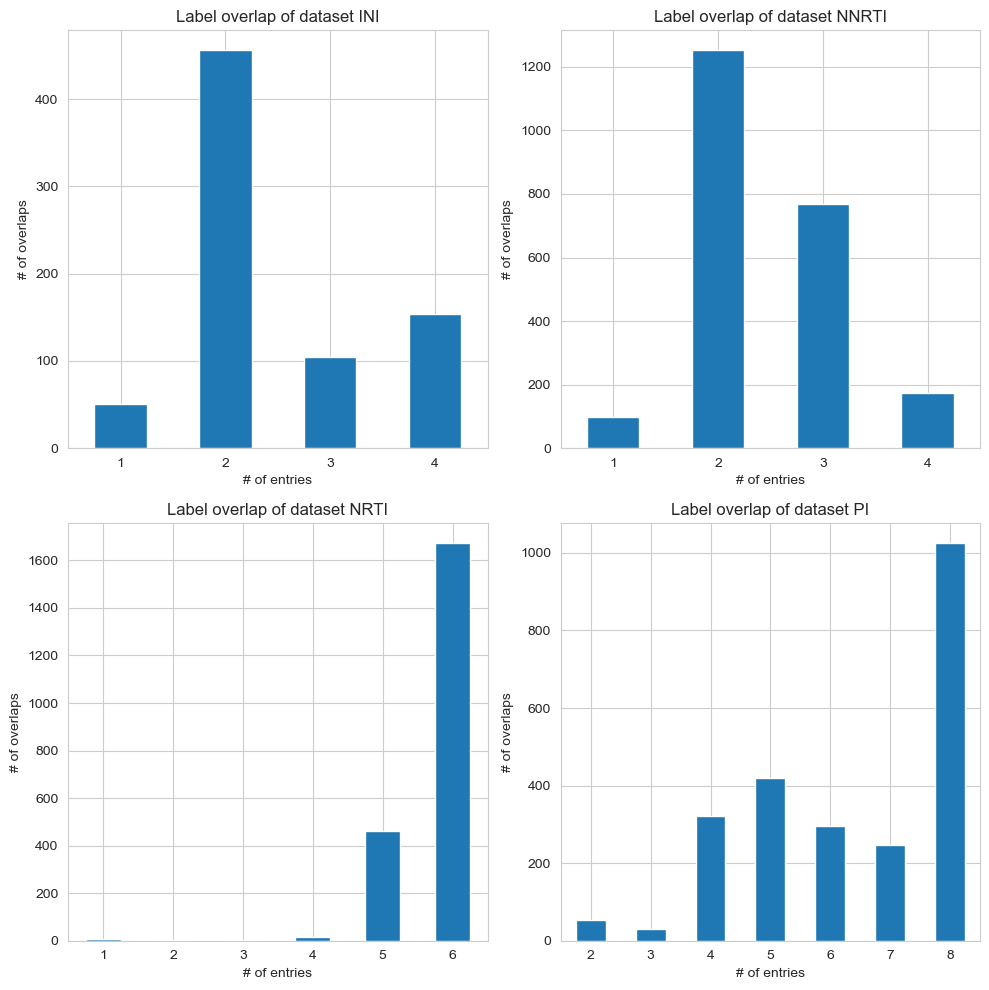

In [58]:
#checking the overlap of labels:

fig, axs = plt.subplots(2, 2, figsize=(10, 10), layout="tight")

axs = axs.flatten()

for i, file in enumerate(files):

    _, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=False)

    labels = Y.loc[:,drugs]

    label_overlap = labels.count(axis=1).value_counts().sort_index()

    ax = axs[i]

    label_overlap.plot(kind="bar", ax=ax)

    ax.tick_params("x", rotation=0)
    ax.set_title('Label overlap of dataset ' + file.split("/")[-1].strip("_DataSet.txt"))
    ax.set_xlabel("# of entries")
    ax.set_ylabel("# of overlaps")

plt.savefig("./figures/target_properties/label_overlap.png")


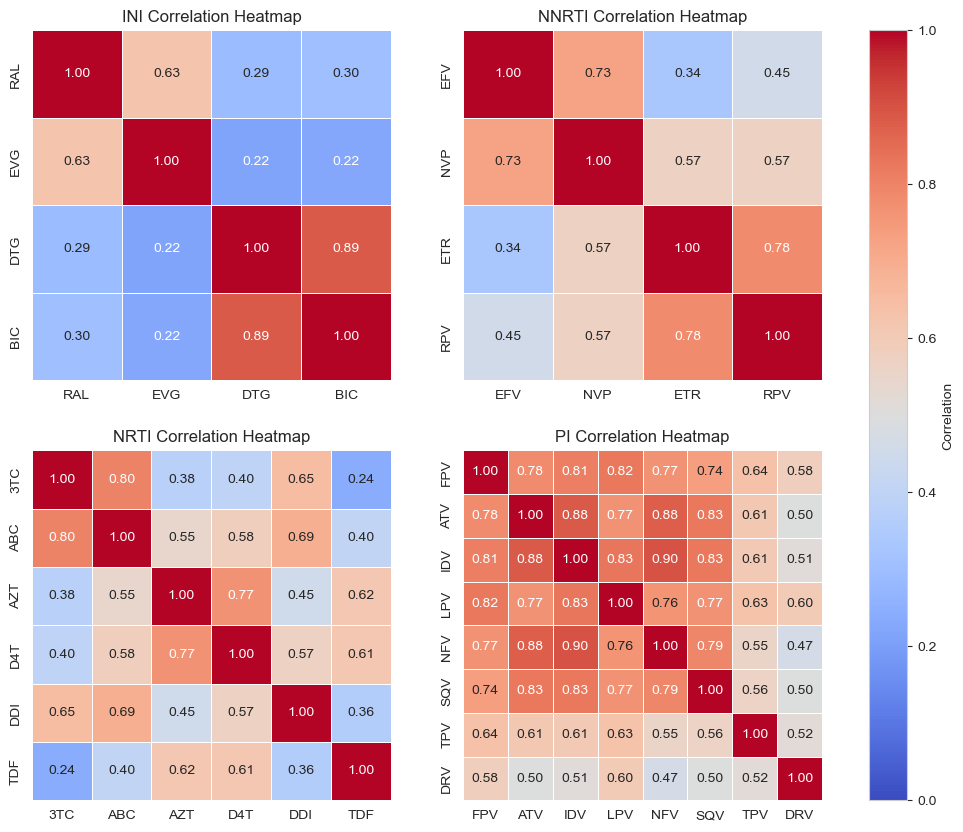

In [63]:

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs = axs.flatten()

last_heatmap = None

for i, file in enumerate(files):
    X, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=True)

    ax = axs[i]

    last_heatmap = sns.heatmap(Y.corr(),vmin=0, vmax = 1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax, cbar=False)
    ax.title.set_text(file.split("/")[-1].strip("_DataSet.txt") + " Correlation Heatmap")

cbar = fig.colorbar(last_heatmap.collections[0], ax=axs, location="right", orientation='vertical', fraction=.1)
cbar.set_label("Correlation")

plt.savefig("./figures/target_properties/corr_heatmaps.png")
